<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/10.%20Model%20Quantization%20Techniques%20-2/Live_Class_Notebook_quantization_2.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [7]:
import os, json, time, copy, struct, warnings, subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers

warnings.filterwarnings("ignore")                    # we re-enable one warning on purpose in Part 6
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available()  else "cpu"   # train/eval fast on the dev box
torch.backends.quantized.engine = "qnnpack"                      # int8 kernels for ARM CPUs

# one small, consistent set of plot colors for the whole class
C_BLUE, C_GREEN, C_MAGENTA, C_YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
C_INK, C_SUBTLE, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
C_GOOD, C_BAD = "#0ca30c", "#d03b3b"     # reserved for pass/fail, always with a text label
plt.rcParams.update({
    "figure.figsize": (7.5, 4), "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": C_AXIS, "axes.labelcolor": C_SUBTLE,
    "axes.titlecolor": C_INK, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2,
})

print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("device      :", DEVICE, "| quantized engine:", torch.backends.quantized.engine)

torch       : 2.11.0+cu128
transformers: 5.12.1
device      : cuda | quantized engine: qnnpack


In [8]:
# ---- one-time downloads (skipped when the files already exist) ----
os.makedirs("data", exist_ok=True); os.makedirs("models/bert-mini", exist_ok=True)

def fetch(url, dest, min_bytes=100):
    if os.path.exists(dest) and os.path.getsize(dest) > min_bytes:
        print(f"[cached]     {dest}")
        return
    subprocess.run(["curl", "-sL", "--max-time", "300", "-o", dest, url], check=True)
    print(f"[downloaded] {dest}  ({os.path.getsize(dest)/1e6:.1f} MB)")

# CLINC150: 22.5k real utterances for exactly Cairn's task (intent routing)
fetch("https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json",
      "data/clinc150.json")

# bert-mini: a 4-layer, 256-hidden BERT pre-trained by Google, re-hosted by prajjwal1
for f in ["pytorch_model.bin", "config.json", "vocab.txt"]:
    fetch(f"https://huggingface.co/prajjwal1/bert-mini/resolve/main/{f}", f"models/bert-mini/{f}")

# The hub copy of bert-mini predates today's transformers: its config.json lacks
# `model_type`, and it ships no tokenizer_config.json (without one, building a
# tokenizer straight from vocab.txt silently maps every word to [UNK] - we learned
# this the hard way). Patch both once so from_pretrained() just works.
cfg = json.load(open("models/bert-mini/config.json"))
if cfg.get("model_type") != "bert":
    cfg["model_type"] = "bert"
    json.dump(cfg, open("models/bert-mini/config.json", "w"), indent=1)
tok_cfg = "models/bert-mini/tokenizer_config.json"
if not os.path.exists(tok_cfg):
    json.dump({"tokenizer_class": "BertTokenizer", "do_lower_case": True,
               "model_max_length": 512}, open(tok_cfg, "w"), indent=1)
print("checkpoint ready")

[cached]     data/clinc150.json
[cached]     models/bert-mini/pytorch_model.bin
[cached]     models/bert-mini/config.json
[cached]     models/bert-mini/vocab.txt
checkpoint ready


In [9]:
# ---- first look at the data Cairn lives on ----
raw = json.load(open("data/clinc150.json"))
for split in ["train", "val", "test"]:
    print(f"{split:5s}: {len(raw[split]):6,d} utterances")

INTENTS = sorted({label for _, label in raw["train"]})
print(f"intents: {len(INTENTS)}  e.g. {INTENTS[:4]} ... {INTENTS[-2:]}")

pd.DataFrame(raw["train"][::2500], columns=["utterance", "intent"])

train: 15,000 utterances
val  :  3,000 utterances
test :  4,500 utterances
intents: 150  e.g. ['accept_reservations', 'account_blocked', 'alarm', 'application_status'] ... ['who_made_you', 'yes']


,utterance,intent
0,what expression would i use to say i love you ...,translate
1,savings account balance at chase bank please,balance
2,tell me my reminders,reminder
3,use a different accent,change_accent
4,tell me when my car last had its oil changed,last_maintenance
5,what's the cheapest fares from lax to sfo for ...,book_flight


In [10]:
from transformers import AutoTokenizer, BertForSequenceClassification, BertConfig

tokenizer = AutoTokenizer.from_pretrained("models/bert-mini")
lab2id = {label: i for i, label in enumerate(INTENTS)}

def encode(rows, max_length=32):
    enc = tokenizer([text for text, _ in rows], padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    labels = torch.tensor([lab2id[label] for _, label in rows])
    return enc["input_ids"], enc["attention_mask"], labels

X_train, M_train, Y_train = encode(raw["train"])
X_val,   M_val,   Y_val   = encode(raw["val"])
X_test,  M_test,  Y_test  = encode(raw["test"])

print("train tensors:", tuple(X_train.shape))
print("a sample, decoded back:", tokenizer.decode(X_train[0][:14]))

train tensors: (15000, 32)
a sample, decoded back: [CLS] what expression would i use to say i love you if i were


In [11]:
X_train[0]

tensor([ 101, 2054, 3670, 2052, 1045, 2224, 2000, 2360, 1045, 2293, 2017, 2065,
        1045, 2020, 2019, 3059,  102,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

In [12]:
M_train[0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
Y_train[0]

tensor(131)

In [14]:
# bert-mini ships as a pre-trained *backbone*; the 150-way classifier head is new (random)
config = BertConfig.from_pretrained("models/bert-mini", num_labels=len(INTENTS))
model = BertForSequenceClassification(config) # this basically adds a new classification head on top of the pre-trained backbone

backbone = torch.load("models/bert-mini/pytorch_model.bin", weights_only=True)

for k, v in backbone.items():
	print(k, v.shape)

bert.embeddings.position_ids torch.Size([1, 512])
bert.embeddings.word_embeddings.weight torch.Size([30522, 256])
bert.embeddings.position_embeddings.weight torch.Size([512, 256])
bert.embeddings.token_type_embeddings.weight torch.Size([2, 256])
bert.embeddings.LayerNorm.weight torch.Size([256])
bert.embeddings.LayerNorm.bias torch.Size([256])
bert.encoder.layer.0.attention.self.query.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.query.bias torch.Size([256])
bert.encoder.layer.0.attention.self.key.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.key.bias torch.Size([256])
bert.encoder.layer.0.attention.self.value.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.value.bias torch.Size([256])
bert.encoder.layer.0.attention.output.dense.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.output.dense.bias torch.Size([256])
bert.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([256])
bert.encoder.layer.0.attention.ou

In [15]:
result = model.bert.load_state_dict({k[len("bert."):]: v for k, v in backbone.items() if k.startswith("bert.")}, strict=False)

print("backbone loaded | missing:", result.missing_keys, "| unexpected:", result.unexpected_keys)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.1f}M  ->  fp32 = {n_params*4/1e6:.1f} MB   (budget B1 is 12 MB)")

backbone loaded | missing: [] | unexpected: ['embeddings.position_ids']
parameters: 11.2M  ->  fp32 = 44.8 MB   (budget B1 is 12 MB)


In [16]:
SPLITS = {"val": (X_val, M_val, Y_val), "test": (X_test, M_test, Y_test)}

def evaluate(m, split="val", batch_size=512, device=DEVICE):
    X, M, Y = SPLITS[split]
    m = m.eval().to(device)
    correct = 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = m(input_ids=X[i:i+batch_size].to(device),
                       attention_mask=M[i:i+batch_size].to(device)).logits
            correct += (logits.argmax(-1).cpu() == Y[i:i+batch_size]).sum().item()
    m.to("cpu")
    return correct / len(X)

def latency_ms(m, iters=100, warmup=20, threads=4):
    m = m.eval().to("cpu")
    x, a = X_val[:1], M_val[:1]
    old = torch.get_num_threads(); torch.set_num_threads(threads)
    times = []
    with torch.no_grad():
        for _ in range(warmup): m(input_ids=x, attention_mask=a)
        for _ in range(iters):
            t = time.perf_counter(); m(input_ids=x, attention_mask=a)
            times.append((time.perf_counter() - t) * 1000)
    torch.set_num_threads(old)
    return float(np.median(times))

def size_mb(state_dict, path="models/_tmp_size_probe.pt"):
    torch.save(state_dict, path)
    mb = os.path.getsize(path) / 1e6
    os.remove(path)
    return mb

print("instruments ready")

instruments ready


In [17]:
# ---- fine-tune Cairn (5 epochs; ~20s on MPS) ----
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
BATCH, EPOCHS = 64, 10
model.to(DEVICE)

t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train))
    losses = []
    for i in range(0, len(X_train), BATCH):
        idx = perm[i:i+BATCH]
        out = model(input_ids=X_train[idx].to(DEVICE), attention_mask=M_train[idx].to(DEVICE),labels=Y_train[idx].to(DEVICE))
        out.loss.backward(); optimizer.step(); optimizer.zero_grad()
        losses.append(out.loss.item())
    val_acc = evaluate(model); model.to(DEVICE)
    print(f"epoch {epoch+1}/{EPOCHS}  train_loss={np.mean(losses):.3f}  val_acc={val_acc:.1%}")
print(f"total: {time.time()-t0:.0f}s")

model = model.to("cpu")
torch.save(model.state_dict(), "models/cairn_fp32.pt")

epoch 1/10  train_loss=4.244  val_acc=65.4%
epoch 2/10  train_loss=2.542  val_acc=79.1%
epoch 3/10  train_loss=1.386  val_acc=86.0%
epoch 4/10  train_loss=0.783  val_acc=90.4%
epoch 5/10  train_loss=0.475  val_acc=91.5%
epoch 6/10  train_loss=0.307  val_acc=92.9%
epoch 7/10  train_loss=0.202  val_acc=92.8%
epoch 8/10  train_loss=0.141  val_acc=93.4%
epoch 9/10  train_loss=0.101  val_acc=93.4%
epoch 10/10  train_loss=0.078  val_acc=93.1%
total: 50s


In [18]:
# ---- the three baseline numbers every later experiment answers to ----
FP32_VAL = evaluate(model, "val")
FP32_MB  = size_mb(model.state_dict())
FP32_MS  = latency_ms(model)

print(f"accuracy (val) : {FP32_VAL:.1%}")
print(f"size on disk   : {FP32_MB:.1f} MB     <- budget B1 says 12 MB: FAIL")
print(f"latency (CPU)  : {FP32_MS:.2f} ms/utterance  <- budget B3 says 30 ms: fine")

accuracy (val) : 93.1%
size on disk   : 44.9 MB     <- budget B1 says 12 MB: FAIL
latency (CPU)  : 20.93 ms/utterance  <- budget B3 says 30 ms: fine


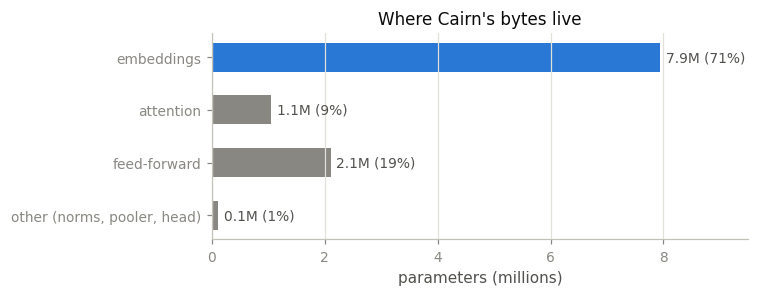

In [19]:
census = {"embeddings": 0, "attention": 0, "feed-forward": 0, "other (norms, pooler, head)": 0}
for name, p in model.named_parameters():
    if "embeddings" in name:                               census["embeddings"] += p.numel()
    elif "attention" in name:                              census["attention"] += p.numel()
    elif "intermediate" in name or "output.dense" in name: census["feed-forward"] += p.numel()
    else:                                                  census["other (norms, pooler, head)"] += p.numel()

fig, ax = plt.subplots(figsize=(7, 2.8))
groups, counts = list(census.keys()), np.array(list(census.values()))
ax.barh(groups[::-1], counts[::-1] / 1e6, color=[C_MUTED, C_MUTED, C_MUTED, C_BLUE], height=0.55)
for i, v in enumerate(counts[::-1] / 1e6):
    ax.text(v + 0.1, i, f"{v:.1f}M ({v*1e6/n_params:.0%})", va="center", fontsize=9, color=C_SUBTLE)
ax.set_xlabel("parameters (millions)"); ax.set_xlim(0, 9.5)
ax.set_title("Where Cairn's bytes live")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [21]:
N_LIN = sum(m.weight.numel() for m in model.modules() if isinstance(m, nn.Linear))
N_EMB = sum(m.weight.numel() for m in model.modules() if isinstance(m, nn.Embedding))
N_OTHER = n_params - N_LIN - N_EMB

print(f"parameter families: linears {N_LIN/n_params:.0%} | embeddings {N_EMB/n_params:.0%} | other {N_OTHER/n_params:.1%}")


parameter families: linears 29% | embeddings 71% | other 0.1%


In [22]:
SCORECARD = []
def scorecard(config, mb, val_acc, latency=None, note=""):
    SCORECARD.append({"config": config, "size MB": round(mb, 1),
                      "val acc": f"{val_acc:.1%}", "Δ vs fp32": f"{val_acc-FP32_VAL:+.1%}",
                      "B1 ≤12MB": "PASS" if mb <= 12 else "fail",
                      "lat ms": round(latency, 2) if latency else "", "note": note})
    return pd.DataFrame(SCORECARD)

scorecard("fp32 baseline", FP32_MB, FP32_VAL, FP32_MS, "as trained")

,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.1%,+0.0%,fail,20.93,as trained


In [23]:
# Storage experiment: weights are STORED in 16 bits; compute runs in fp32
# (exactly what a deployment does when the CPU has no native fp16 math).
model_fp16 = copy.deepcopy(model).half()
model_bf16 = copy.deepcopy(model).bfloat16()

fp16_mb = size_mb(model_fp16.state_dict())
bf16_mb = size_mb(model_bf16.state_dict())

acc_fp16 = evaluate(model_fp16.float())
acc_bf16 = evaluate(model_bf16.float())

print(f"fp16: {fp16_mb:.1f} MB  val {acc_fp16:.1%}  (fp32: {FP32_VAL:.1%})")
print(f"bf16: {bf16_mb:.1f} MB  val {acc_bf16:.1%}")
scorecard("fp16 weights", fp16_mb, acc_fp16, note="pure cast, free")
scorecard("bf16 weights", bf16_mb, acc_bf16, note="pure cast, free")

fp16: 22.4 MB  val 93.1%  (fp32: 93.1%)
bf16: 22.4 MB  val 93.1%


,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.1%,+0.0%,fail,20.93,as trained
1,fp16 weights,22.4,93.1%,+0.0%,fail,,"pure cast, free"
2,bf16 weights,22.4,93.1%,-0.0%,fail,,"pure cast, free"


# Quantization Int8 - Asymmetric and Symmetric

In [25]:
def quantize_asym(x, bits=8):
    qmax = 2 ** bits - 1                                # int8 -> 255 codes (uint8-style)
    r_min, r_max = x.min(), x.max()
    scale = ((r_max - r_min) / qmax).clamp(min=1e-12)
    zero_point = int((-r_min / scale).round().clamp(0, qmax))
    q = torch.clamp((x / scale).round() + zero_point, 0, qmax)
    return q.to(torch.uint8), scale.item(), zero_point

def quantize_sym(x, bits=8):
    qmax = 2 ** (bits - 1) - 1                          # int8 -> 127
    scale = x.abs().max().clamp(min=1e-12) / qmax
    q = torch.clamp((x / scale).round(), -qmax - 1, qmax)
    return q.to(torch.int8), scale.item()

def dequantize(q, scale, zero_point=0):
    return (q.float() - zero_point) * scale

# 8

# 0 - 2 ^ 8 - 1 = 255
# 0 - 2^7 - 1


**The rule of thumb almost every production stack follows:**

| tensor | scheme | why |
|---|---|---|
| **weights** | symmetric, `zero_point = 0` | zero-centred by nature; zp=0 removes cross-terms from the int-matmul (faster kernels) |
| **activations** | asymmetric | GELU/ReLU/softmax outputs are one-sided or skewed; the zero_point recovers the wasted half of the map |

In [32]:
m_int8 = copy.deepcopy(model)

for module in m_int8.modules():
    if isinstance(module, nn.Linear):
        q, scale = quantize_sym(module.weight.data, bits=8)   # weights -> 256 integer codes + ONE scale
        module.weight.data = dequantize(q, scale)



acc_int8 = evaluate(m_int8)
print(f"int8 weights, per-tensor symmetric: val {acc_int8:.1%}   (fp32 {FP32_VAL:.1%})")



int8 weights, per-tensor symmetric: val 93.1%   (fp32 93.1%)


In [33]:
size_mb(m_int8.state_dict())

44.866048

Take symmetric INT4, so integer codes are `-7 … 7`.

```text
q = round(w / scale)
ŵ = q × scale
```

Use this `10 × 5` weight matrix:

```text
W =
[-0.10, 0.05, 0.12, -0.08, 0.02]
[-0.25, 0.10, 0.30, -0.20, 0.05]
[-0.50, 0.20, 0.70, -0.40, 0.10]
[-1.00, 0.40, 1.40, -0.80, 0.20]
[-2.00, 0.80, 2.80, -1.60, 0.40]
[-0.15, 0.05, 0.20, -0.10, 0.02]
[-0.35, 0.10, 0.45, -0.25, 0.08]
[-0.80, 0.30, 1.00, -0.60, 0.15]
[-1.50, 0.50, 2.00, -1.00, 0.25]
[-3.00, 1.00, 4.00, -2.00, 0.50]
```

## 1. Per-tensor

One scale for all 50 weights:

```text
scale = max(|W|) / 7
      = 4 / 7
      = 0.5714
```

Quantized codes:

```text
[ 0, 0, 0,  0, 0]
[ 0, 0, 1,  0, 0]
[-1, 0, 1, -1, 0]
[-2, 1, 2, -1, 0]
[-4, 1, 5, -3, 1]
[ 0, 0, 0,  0, 0]
[-1, 0, 1,  0, 0]
[-1, 1, 2, -1, 0]
[-3, 1, 4, -2, 0]
[-5, 2, 7, -4, 1]
```

The first row becomes entirely zero because its values are tiny relative to the global scale.

## 2. Per-channel

Each row gets its own scale:

```text
row 1: 0.12 / 7 = 0.0171
row 2: 0.30 / 7 = 0.0429
row 3: 0.70 / 7 = 0.1000
row 4: 1.40 / 7 = 0.2000
row 5: 2.80 / 7 = 0.4000
row 6: 0.20 / 7 = 0.0286
row 7: 0.45 / 7 = 0.0643
row 8: 1.00 / 7 = 0.1429
row 9: 2.00 / 7 = 0.2857
row 10: 4.00 / 7 = 0.5714
```

Quantized codes:

```text
[-6, 3, 7, -5, 1]
[-6, 2, 7, -5, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-6, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
```

The first row dequantizes to approximately:

```text
[-0.1029, 0.0514, 0.1200, -0.0857, 0.0171]
```

Much better than becoming all zeros.

## 3. Per-group

Take group size `2`. Within each row:

```text
[w1, w2] | [w3, w4] | [w5]
```

For the first row:

```text
[-0.10, 0.05] | [0.12, -0.08] | [0.02]
```

Scales:

```text
group 1: 0.10 / 7 = 0.0143
group 2: 0.12 / 7 = 0.0171
group 3: 0.02 / 7 = 0.00286
```

Codes:

```text
[-7, 4] | [7, -5] | [7]
```

Dequantized:

```text
[-0.1000, 0.0571, 0.1200, -0.0857, 0.0200]
```

This is slightly more accurate than per-channel because each smaller region gets its own scale.

Our notebook’s `view(out, inp // group, group)` requires the number of columns to be divisible by the group size. For a `10 × 5` matrix and group size `2`, production code would pad or handle the final smaller group separately.


In [34]:
def qdq_weight(w, bits=8, mode="channel", group=64):
    # symmetric quantize->dequantize of one 2D weight, at three granularities
    qmax = 2 ** (bits - 1) - 1
    if mode == "tensor":
        scale = w.abs().max().clamp(min=1e-12) / qmax                             # 1 scale
    elif mode == "channel":
        scale = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-12) / qmax         # 1 per row
    elif mode == "group":
        out, inp = w.shape
        wg = w.view(out, inp // group, group)                                     # 1 per 64 weights
        scale = wg.abs().amax(dim=2, keepdim=True).clamp(min=1e-12) / qmax
        return (torch.clamp((wg / scale).round(), -qmax - 1, qmax) * scale).view(out, inp)
    return torch.clamp((w / scale).round(), -qmax - 1, qmax) * scale

def quantize_weights(m, bits=8, mode="channel", group=64, embedding_bits=None):
    # simulated weight quantization for a whole model (works on ANY model of Linears/Embeddings)
    out = copy.deepcopy(m).cpu()
    with torch.no_grad():
        for module in out.modules():
            if isinstance(module, nn.Linear):
                use = mode
                module.weight.data = qdq_weight(module.weight.data, bits, use, group)
            elif embedding_bits and isinstance(module, nn.Embedding):
                module.weight.data = qdq_weight(module.weight.data, embedding_bits, "channel")
    return out

results = {}
for mode in ["tensor", "channel", "group"]:
    results[mode] = evaluate(quantize_weights(model, bits=4, mode=mode))
    print(f"int4 weights, per-{mode:7s}: val {results[mode]:.1%}")

int4 weights, per-tensor : val 76.1%
int4 weights, per-channel: val 92.8%
int4 weights, per-group  : val 92.8%


In [35]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_dyn = torch.ao.quantization.quantize_dynamic(copy.deepcopy(model), {nn.Linear}, dtype=torch.qint8)

msg = next((str(w.message) for w in caught if "deprecat" in str(w.message).lower()), "(no warning raised)")
print("PyTorch says:\n")
print("  " + msg.split("For migrations")[0].strip())
print()
print(type(model_dyn.bert.encoder.layer[0].attention.self.query).__name__, "<- Linears became real int8 modules")

PyTorch says:

  torch.ao.quantization is deprecated and will be removed in 2.10.

Linear <- Linears became real int8 modules


In [36]:
acc_dyn = evaluate(model_dyn, device="cpu")               # quantized kernels are CPU-only
dyn_mb  = size_mb(model_dyn.state_dict())
print(f"dynamic int8:  val {acc_dyn:.1%}   file {dyn_mb:.1f} MB   <- wait. {dyn_mb:.0f} MB?!")
scorecard("torch quantize_dynamic (REAL)", dyn_mb, acc_dyn, note="one line; but check the file size!")

dynamic int8:  val 93.0%   file 35.1 MB   <- wait. 35 MB?!


,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.1%,+0.0%,fail,20.93,as trained
1,fp16 weights,22.4,93.1%,+0.0%,fail,,"pure cast, free"
2,bf16 weights,22.4,93.1%,-0.0%,fail,,"pure cast, free"
3,torch quantize_dynamic (REAL),35.1,93.0%,-0.1%,fail,,one line; but check the file size!


In [40]:
from torchao.quantization import quantize_, Int8WeightOnlyConfig

model_ao = copy.deepcopy(model)
quantize_(model_ao, Int8WeightOnlyConfig())    # this doesn't return anything quantizes in place      # weight-only int8, in place
acc_ao = evaluate(model_ao, device="cpu")

# w = model_ao.bert.encoder.layer[0].attention.self.query.weight
print(f"torchao int8 weight-only: val {acc_ao:.1%}")
print(f"the weight is now a {type(w).__name__} - a tensor that carries its own map:")
# print(f"  int codes: {w.qdata.dtype}   scales: {tuple(w.scale.shape)}")
# print(f"  -> one scale per output channel: per-channel symmetric, exactly our Part 4 recipe")
scorecard("torch torchao int8 weight-only", size_mb(model_ao.state_dict()), acc_ao, note="one line; but check the file size!")

torchao int8 weight-only: val 93.1%
the weight is now a AffineQuantizedTensor - a tensor that carries its own map:


,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.1%,+0.0%,fail,20.93,as trained
1,fp16 weights,22.4,93.1%,+0.0%,fail,,"pure cast, free"
2,bf16 weights,22.4,93.1%,-0.0%,fail,,"pure cast, free"
3,torch quantize_dynamic (REAL),35.1,93.0%,-0.1%,fail,,one line; but check the file size!
4,torch torchao int8 weight-only,35.3,93.1%,-0.0%,fail,,one line; but check the file size!


In [41]:
## save it

save_dir = "models/cairn_int8_torchao"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_ao.state_dict(), f"{save_dir}/weights.pt")
model.config.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

('models/cairn_int8_torchao/tokenizer_config.json',
 'models/cairn_int8_torchao/tokenizer.json')

In [42]:
## load it

import torch
from transformers import BertConfig, BertForSequenceClassification, AutoTokenizer

save_dir = "models/cairn_int8_torchao"

config = BertConfig.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

# Avoid allocating an unnecessary FP32 model.
with torch.device("meta"):
    loaded_model = BertForSequenceClassification(config)

state_dict = torch.load(
    f"{save_dir}/weights.pt",
    map_location="cpu",
)

loaded_model.load_state_dict(state_dict, assign=True)
#That replaces the newly created ordinary parameters with torchao’s saved quantized tensor objects. You do not call quantize_() again after loading. Initializing on the meta device avoids temporarily creating the full FP32 weights.

#assign=False → preserve destination tensor type; copy values
#assign=True  → preserve checkpoint tensor type/properties
loaded_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 256, padding_idx=0)
      (position_embeddings): Embedding(512, 256)
      (token_type_embeddings): Embedding(2, 256)
      (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=256, out_features=256, bias=True)
              (LayerNorm): LayerNorm((256,), eps=1e-12, e